# Hierarchical Refinement with OTT‑JAX: Scalable Optimal Transport


### This notebook is a hands‑on tutorial showing how to implement Hierarchical Refinement using the low‑rank LRSinkhorn solver from ```OTT‑JAX```.

We experiment with the implementation of Hierachical Refinement based on the low-rank LRSinkhorn solver, proposed by [Halmos et al., 2025]([text](https://arxiv.org/pdf/2503.03025)). 
This algorithm to scalably compute a full-rank, bijective alignment between two equally-sized input datasets X and Y by solving a hierarchy of low-rank OT sub-problems. 

___

**1. Installation & Setup**
* Installing OTT‑JAX and dependencies  

**2. Generating Synthetic Data** 
* Creating two toy point clouds of equal cardinality,  each with a uniform mass
* Visualizing source and target  

**3. Low‑Rank partitions with LRSinkhorn**  
* Formulating the rank‑2 Sinkhorn problem  
* Using `Rank2Initializer` for deterministic splits  
* Inspecting the per‑scale soft‑clusters  

**4. Building Hierarchical Refinement (HiRef)**
* Recursive partitioning into sub‑blocks  
* Tracking original indices to recover a bijection  
* Putting it all together in a reusable function  

**5. Visualizing Multiscale Alignments**  
* Plotting co‑cluster assignments at each level  
* Drawing arrows for final Monge map 

## 1. Installation & Setup

* Installing OTT‑JAX and dependencies with requirements.txt

* Import of libraries: The proposed approach to implement HiRef algorithm use the OTT - JAX library and it is low rank Sinkhorn algorithm

* We strongly recommend to use the **```0.5.0``` version** which is the latest stable version of ```OTT-JAX```

In [1]:
!pip install -r ../requirements.txt

In [2]:
import jax
import jax.numpy as jnp

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

import matplotlib.pyplot as plt # Pour tracer les graphiques

In [3]:
import ott
print("OTT‑JAX version:", ott.__version__)

OTT‑JAX version: 0.5.0


## 2. Generating Synthetic Data
* Standard version of HiRef algorithm requires points clouds to be both **same size** and with **uniform mass**


In [4]:
def create_points(rng, n, d):
    """
    Generate two toy point clouds of equal size and dimension.

    Parameters
    ----------
    rng : jax.random.PRNGKey
        A JAX random number generator key.
    n : int
        The number of points in each point cloud.
    d : int
        The dimensionality of each point.

    Returns
    -------
    x : jnp.ndarray of shape (n, d)
        Point cloud drawn from a standard normal distribution.
    y : jnp.ndarray of shape (n, d)
        Point cloud drawn from a uniform distribution on [4, 8).
    """
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.uniform(rngs[1], (n, d), minval=4, maxval=8)
    return x, y

In [5]:
rng = jax.random.key(4)
n, d = 100, 2
x, y = create_points(rng, n=n, d=d)

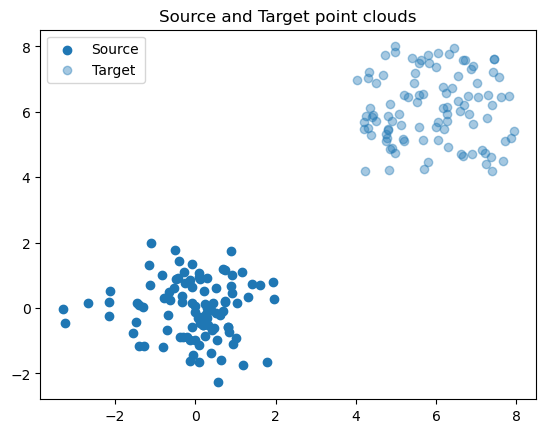

In [6]:
plt.scatter(x[:, 0], x[:, 1], label="Source", color="#1f77b4", alpha=1)
plt.scatter(y[:, 0], y[:, 1], label="Target", color="#1f77b4", alpha=0.4)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

## 3. Low‑Rank partitions with LRSinkhorn

* I use LRSinkhorn with rank = 2 to partition into 2 subparts my pointclouds X (```Proposition 3.1``` ensures optimality of the solution)

* Use of of **determistic** ```Rank2Initialize``` initializer
    > Construit « à la main » 2 blocs de taille uniforme (un hard‑clustering trivial) puis étend à rang r via un schéma analytique simple.

* Very important that gamma value is high (>100) 

* Use of JIT compilation with ```jax.jit``` to speed up algorithm execution 

In [7]:
def low_rank_partition(x_block: jnp.ndarray,
                       y_block: jnp.ndarray,
                       rank: int = 2):
    """
    Renvoie pour chaque point de x_block et y_block 
    son indice de cluster {0,1} à rang=2, 
    en initialisant avec Rank2Initializer.
    """
    # 1) Problème OT
    geom    = pointcloud.PointCloud(x_block, y_block)
    n       = x_block.shape[0]
    a       = jnp.ones(n) / n
    ot_prob = linear_problem.LinearProblem(geom)

    # 2) Initialiser avec Rank2Initializer (déterministe)
    init    = Rank2Initializer(rank=rank)

    # 3) Créer le solver low‑rank Sinkhorn
    solver  = jax.jit(LRSinkhorn(rank=rank, initializer=init, gamma=50000)) # Very important that gamma value is high (>100) 

    # 4) Lancer la résolution (pas besoin de jit pour du debug)
    out     = solver(ot_prob)

    # 5) Les deux soft‑clustering Q et R → argmax pour labels {0,1}
    Q, R, G    = out.q, out.r, out.g

    partition_x = jnp.argmax(Q, axis=1)
    partition_y = jnp.argmax(R, axis=1)

    return partition_x, partition_y, (Q,R,G)

In [8]:
# --- Exemple d’usage ---
partition_x, partition_y, matrice = low_rank_partition(x, y)

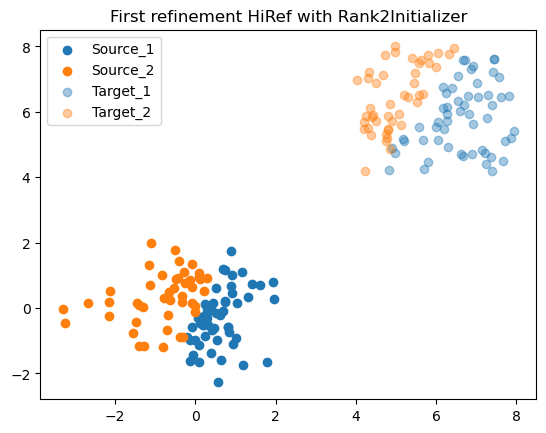

In [9]:
# Masques et affichage
mask_x1 = (partition_x == 0)
mask_x2 = ~mask_x1
mask_y1 = (partition_y == 0)
mask_y2 = ~mask_y1

import matplotlib.pyplot as plt
plt.scatter(x[mask_x1,0], x[mask_x1,1], color="#1f77b4", label="Source_1", alpha=1)
plt.scatter(x[mask_x2,0], x[mask_x2,1], color="#ff7f0e", label="Source_2", alpha=1)
plt.scatter(y[mask_y1,0], y[mask_y1,1], color="#1f77b4", label="Target_1", alpha=0.4)
plt.scatter(y[mask_y2,0], y[mask_y2,1], color="#ff7f0e", label="Target_2", alpha=0.4)
plt.legend(); plt.title("First refinement HiRef with Rank2Initializer"); plt.show()

## 4. Building Hierarchical Refinement (HiRef)



In [10]:
def hiref(x: jnp.ndarray,
          y: jnp.ndarray,
          x_idx: jnp.ndarray = None,
          y_idx: jnp.ndarray = None,
          rank: int = 2,
          base_size: int = 1):
    """
    Hierarchical Refinement: retourne une liste de couples (i,j)
    où i,j sont des indices dans le dataset original.
    """
    # Initialisation des index originaux
    if x_idx is None:
        x_idx = jnp.arange(x.shape[0])
    if y_idx is None:
        y_idx = jnp.arange(y.shape[0])

    n = x.shape[0]
    # Cas de base : bloc de taille 1 → on mappe directement les deux points
    if n <= base_size:
        return [(int(x_idx[0]), int(y_idx[0]))]

    # 1) Partition low-rank rang=2
    lab_x, lab_y, matrice = low_rank_partition(x, y, rank=rank)

    pairs = []
    # 2) Pour chaque sous-bloc z=0 et z=1
    for z in range(rank):
        mask_x    = (lab_x == z)
        mask_y    = (lab_y == z)
        x_sub     = x[mask_x]
        y_sub     = y[mask_y]
        x_idx_sub = x_idx[mask_x]
        y_idx_sub = y_idx[mask_y]

        # 3) Récursion
        pairs.extend(hiref(x_sub, y_sub,
                           x_idx=x_idx_sub,
                           y_idx=y_idx_sub,
                           rank=rank,
                           base_size=base_size))
    return pairs

In [11]:
pairs = hiref(x, y, base_size=1)

# 4) Construction de la matrice de transport bijective P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# 5) Vérification
assert jnp.all(P.sum(axis=1) == 1)
assert jnp.all(P.sum(axis=0) == 1)

# 5. Visualizing Multiscale Alignments

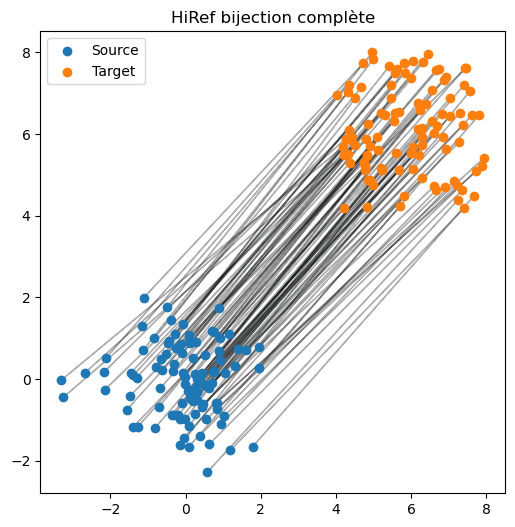

In [12]:
plt.figure(figsize=(6,6))
for i, j in pairs:
    plt.arrow(x[i,0], x[i,1],
              y[j,0] - x[i,0],
              y[j,1] - x[i,1],
              head_width=0.05, alpha=0.3, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], c='C0', label='Source')
plt.scatter(y[:,0], y[:,1], c='C1', label='Target')
plt.legend(); plt.title("HiRef bijection complète"); plt.show()

## 6. Next Step

* AMéliorer les explications du notebooks
* Regarder s'il est possible d'améliorer l'efficacité de l'algorithme
* implémenter rank-annealing scheldule